In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df1 = pd.read_csv('dados/dados_modelo1.csv')
df2 = pd.read_csv('dados/dados_modelo2.csv')
df3 = pd.read_csv('dados/dados_modelo3.csv')
df1_test = pd.read_csv('dados/dados_teste1.csv')
df2_test = pd.read_csv('dados/dados_teste2.csv')
df3_test = pd.read_csv('dados/dados_teste3.csv')

### 1- Dividindo as features e a resposta

In [3]:
X1_train = df1.drop('Reprovou', axis = 1)
y1_train = df1['Reprovou']
# X1.drop('TempoQ3', axis = 1, inplace = True)

X2_train = df2.drop('Reprovou', axis = 1)
y2_train = df2['Reprovou']
# X2.drop('TempoQ3', axis = 1, inplace = True)

X3_train = df3.drop('Reprovou', axis = 1)
y3_train = df3['Reprovou']
# X3.drop('TempoQ3', axis = 1, inplace = True)

X1_test = df1_test.drop('Reprovou', axis = 1)
y1_test = df1_test['Reprovou']
# X1.drop('TempoQ3', axis = 1, inplace = True)

X2_test = df2_test.drop('Reprovou', axis = 1)
y2_test = df2_test['Reprovou']
# X2.drop('TempoQ3', axis = 1, inplace = True)

X3_test = df3_test.drop('Reprovou', axis = 1)
y3_test = df3_test['Reprovou']
# X3.drop('TempoQ3', axis = 1, inplace = True)


In [4]:
X1_train["Produto_Quizzes"] = X1_train[["Quiz1","Quiz2","Quiz3"]].prod(axis=1)
X2_train["Produto_Quizzes"] = X2_train[["Quiz1","Quiz2","Quiz3","Quiz4"]].prod(axis=1)
X3_train["Produto_Quizzes"] = X3_train[["Quiz1","Quiz2","Quiz3","Quiz4","Quiz5","Quiz6"]].prod(axis=1)

X1_test["Produto_Quizzes"] = X1_test[["Quiz1","Quiz2","Quiz3"]].prod(axis=1)
X2_test["Produto_Quizzes"] = X2_test[["Quiz1","Quiz2","Quiz3","Quiz4"]].prod(axis=1)
X3_test["Produto_Quizzes"] = X3_test[["Quiz1","Quiz2","Quiz3","Quiz4","Quiz5","Quiz6"]].prod(axis=1)

X1_train["prod_tempo"] = X1_train[['TempoQ1', 'TempoQ2']].prod(axis=1)
X2_train["prod_tempo"] = X2_train[['TempoQ1', 'TempoQ2']].prod(axis=1)
X3_train["prod_tempo"] = X3_train[['TempoQ1', 'TempoQ2']].prod(axis=1)

X1_test["prod_tempo"] = X1_test[["Quiz1","Quiz2","Quiz3"]].prod(axis=1)
X2_test["prod_tempo"] = X2_test[["Quiz1","Quiz2","Quiz3","Quiz4"]].prod(axis=1)
X3_test["prod_tempo"] = X3_test[["Quiz1","Quiz2","Quiz3","Quiz4","Quiz5","Quiz6"]].prod(axis=1)



### 2- Preenchendo valores nulos no tempo do quizz 3

In [5]:
X1_train['TempoQ3'] = X1_train['TempoQ3'].fillna(0)
X2_train['TempoQ3'] = X2_train['TempoQ3'].fillna(0)
X3_train['TempoQ3'] = X3_train['TempoQ3'].fillna(0)



### 3- Splitando os tres data frames e treinando o modelo

Melhores parâmetros: NearestCentroid(metric='manhattan')
Recall da classe 0 no teste: 0.7692307692307693


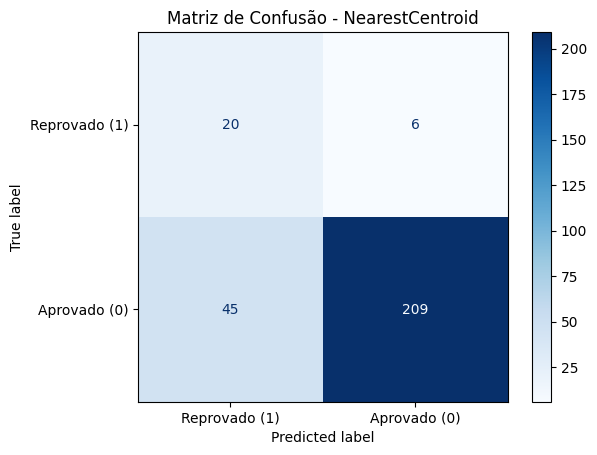

In [6]:

# X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1,test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X1_train, y1_train = sm.fit_resample(X1_train, y1_train)

# Definição do classificador
nc = NearestCentroid()

# Grid de parâmetros
param_grid = {
    "metric": ["euclidean", "manhattan"],  
    "shrink_threshold": [None, 0.1, 0.5, 1.0]
}


grid1 = GridSearchCV(nc, param_grid, cv=5, scoring='recall')
grid1.fit(X1_train, y1_train)

melhor_modelo1nc = grid1.best_estimator_

print("Melhores parâmetros:", melhor_modelo1nc)

y1_pred = grid1.predict(X1_test)
recall_classe_0 = recall_score(y1_test, y1_pred)
print("Recall da classe 0 no teste:", recall_classe_0)

confusion_matrix(y1_test, y1_pred, labels=[1,0])

disp = ConfusionMatrixDisplay.from_predictions(
    y1_test,
    y1_pred,
    display_labels=["Reprovado (1)", "Aprovado (0)"],  
    cmap="Blues",
    values_format="d",
    labels = [1,0]
)

plt.title("Matriz de Confusão - NearestCentroid")
plt.show()


Melhores parâmetros: NearestCentroid(metric='manhattan', shrink_threshold=np.float64(0.4))
Recall da classe 0 no teste: 0.8076923076923077


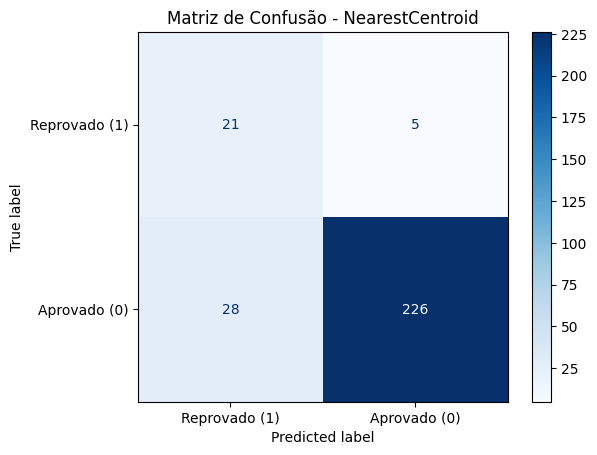

In [7]:


# X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1,test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X2_train, y2_train = sm.fit_resample(X2_train, y2_train)

# Definição do classificador
nc = NearestCentroid()

# Grid de parâmetros
param_grid = {
    "metric": ["euclidean", "manhattan"],  
    "shrink_threshold": list(np.arange(0.1, 1, 0.1))
}


grid2 = GridSearchCV(nc, param_grid, cv=5, scoring='recall')
grid2.fit(X2_train, y2_train)

melhor_modelo2nc = grid2.best_estimator_

print("Melhores parâmetros:", melhor_modelo2nc)

y2_pred = grid2.predict(X2_test)
recall_classe_0 = recall_score(y2_test, y2_pred)
print("Recall da classe 0 no teste:", recall_classe_0)

confusion_matrix(y2_test, y2_pred, labels=[1,0])

disp = ConfusionMatrixDisplay.from_predictions(
    y2_test,
    y2_pred,
    display_labels=["Reprovado (1)", "Aprovado (0)"],  
    cmap="Blues",
    values_format="d",
    labels = [1,0]
)

plt.title("Matriz de Confusão - NearestCentroid")
plt.show()


Melhores parâmetros: NearestCentroid(metric='manhattan')
Recall da classe 0 no teste: 0.7307692307692307


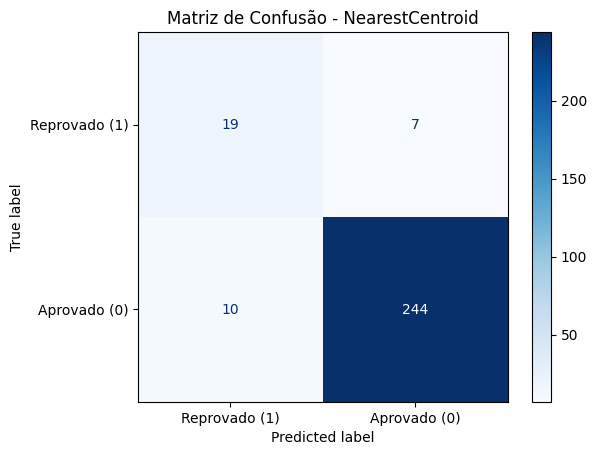

In [8]:

# X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1,test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X3_train, y3_train = sm.fit_resample(X3_train, y3_train)

# Definição do classificador
nc = NearestCentroid()

# Grid de parâmetros
param_grid = {
    "metric": ["euclidean", "manhattan"],  
    "shrink_threshold": [None, 0.1, 0.5, 1.0]
}


grid3 = GridSearchCV(nc, param_grid, cv=5, scoring='recall')
grid3.fit(X3_train, y3_train)

melhor_modelo3nc = grid3.best_estimator_

print("Melhores parâmetros:", melhor_modelo3nc)

y3_pred = grid3.predict(X3_test)
recall_classe_0 = recall_score(y3_test, y3_pred)
print("Recall da classe 0 no teste:", recall_classe_0)

confusion_matrix(y3_test, y3_pred, labels=[1,0])

disp = ConfusionMatrixDisplay.from_predictions(
    y3_test,
    y3_pred,
    display_labels=["Reprovado (1)", "Aprovado (0)"],  
    cmap="Blues",
    values_format="d",
    labels = [1,0]
)

plt.title("Matriz de Confusão - NearestCentroid")
plt.show()


In [9]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Se ainda não dividiu os dados
# X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Aplicando SMOTE apenas no treino
sm = SMOTE(random_state=42)
X1_train, y1_train = sm.fit_resample(X1_train, y1_train)

# Definição do classificador com parâmetros default
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Treinando o modelo
xgb.fit(X1_train, y1_train)

# Previsões no conjunto de teste
y1_pred = xgb.predict(X1_test)

# Recall da classe 0 
recall_classe_0 = recall_score(y1_test, y1_pred)
print("Recall da classe 0 no teste:", recall_classe_0)


# Matriz de confusão
cm = confusion_matrix(y1_test, y1_pred, labels=[1,0])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Reprovado (1)", "Aprovado (0)"]
)
disp.plot(cmap="Blues", values_format="d")

plt.title("Matriz de Confusão - XGBClassifier")
plt.show()


ModuleNotFoundError: No module named 'xgboost'

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:51:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Recall da classe 0 no teste: 0.34615384615384615


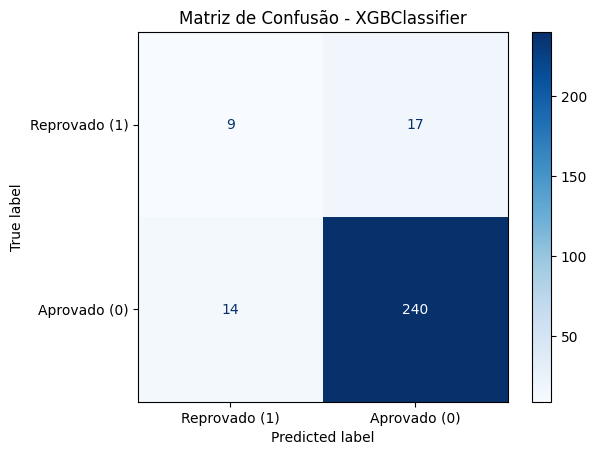

In [ ]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Se ainda não dividiu os dados
# X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Aplicando SMOTE apenas no treino
sm = SMOTE(random_state=42)
X2_train, y2_train = sm.fit_resample(X2_train, y2_train)

# Definição do classificador com parâmetros default
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Treinando o modelo
xgb.fit(X2_train, y2_train)

# Previsões no conjunto de teste
y2_pred = xgb.predict(X2_test)

# Recall da classe 0 
recall_classe_0 = recall_score(y2_test, y2_pred)
print("Recall da classe 0 no teste:", recall_classe_0)

# Matriz de confusão
cm = confusion_matrix(y2_test, y2_pred, labels=[1,0])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Reprovado (1)", "Aprovado (0)"]
)
disp.plot(cmap="Blues", values_format="d")

plt.title("Matriz de Confusão - XGBClassifier")
plt.show()


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:51:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Recall da classe 0 no teste: 0.4230769230769231


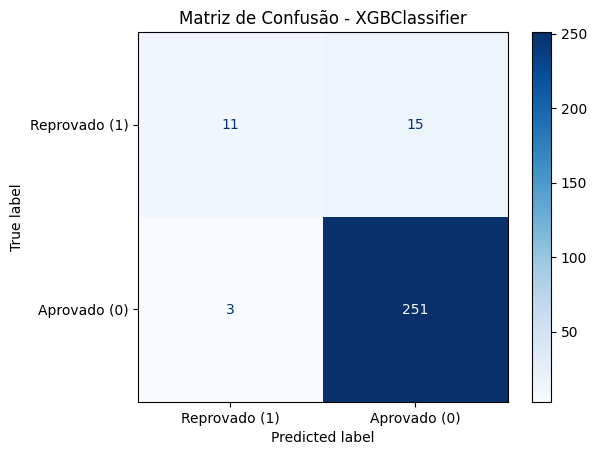

In [ ]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Se ainda não dividiu os dados
# X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Aplicando SMOTE apenas no treino
sm = SMOTE(random_state=42)
X3_train, y3_train = sm.fit_resample(X3_train, y3_train)

# Definição do classificador com parâmetros default
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Treinando o modelo
xgb.fit(X3_train, y3_train)

# Previsões no conjunto de teste
y3_pred = xgb.predict(X3_test)

# Recall da classe 0 
recall_classe_0 = recall_score(y3_test, y3_pred)
print("Recall da classe 0 no teste:", recall_classe_0)


# Matriz de confusão
cm = confusion_matrix(y3_test, y3_pred, labels=[1,0])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Reprovado (1)", "Aprovado (0)"]
)
disp.plot(cmap="Blues", values_format="d")

plt.title("Matriz de Confusão - XGBClassifier")
plt.show()


In [ ]:
from lazypredict.Supervised import LazyClassifier


def recall(y_true, y_pred):
    return recall_score(y_true, y_pred, average='macro')

clf = LazyClassifier(verbose = 0, custom_metric=recall)

models, predicts = clf.fit(X1_train, X1_test, y1_train, y1_test)

print(models)
print(predicts)


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 1041, number of negative: 1041
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000313 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1982
[LightGBM] [Info] Number of data points in the train set: 2082, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
AdaBoostClassifier                 0.76               0.75     0.75      0.80   
BernoulliNB                        0.81               0.72     0.72      0.84   
XGBClassifier                      0.70               0.71     0.71      0.76   
LGBMClassifier                     0.76               0.71     0.71      0.80   
LogisticRegres

In [ ]:
from lazypredict.Supervised import LazyClassifier


def recall(y_true, y_pred):
    return recall_score(y_true, y_pred, average='macro')

clf = LazyClassifier(verbose = 0, custom_metric=recall)

models, predicts = clf.fit(X2_train, X2_test, y2_train, y2_test)

print(models)
print(predicts)


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 1041, number of negative: 1041
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000188 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2749
[LightGBM] [Info] Number of data points in the train set: 2082, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
GaussianNB                         0.88               0.79     0.79      0.89   
PassiveAggressiveClassifier        0.87               0.79     0.79      0.88   
Perceptron                         0.90               0.79     0.79      0.90   
CalibratedClassifierCV             0.91               0.78     0.78      0.91   
LinearSVC                          0.91               0.78     0.78      0.91 

In [ ]:
from lazypredict.Supervised import LazyClassifier


def recall(y_true, y_pred):
    return recall_score(y_true, y_pred, average='macro')

clf = LazyClassifier(verbose = 0, custom_metric=recall)

models, predicts = clf.fit(X3_train, X3_test, y3_train, y3_test)

print(models)
print(predicts)


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 1041, number of negative: 1041
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000208 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3604
[LightGBM] [Info] Number of data points in the train set: 2082, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
CalibratedClassifierCV             0.94               0.83     0.83      0.94   
LinearSVC                          0.94               0.83     0.83      0.94   
GaussianNB                         0.89               0.82     0.82      0.90   
Perceptron                         0.92               0.82     0.82      0.92   
NuSVC                              0.94               0.81     0.81      0.94 

Recall da classe 0 no teste: 0.7307692307692307


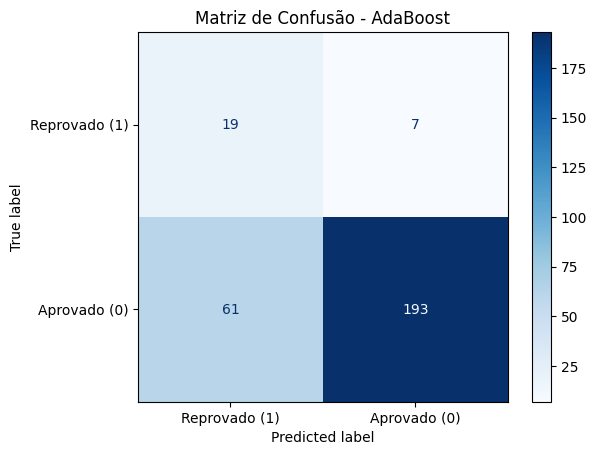

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Se ainda não dividiu os dados
# X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Aplicando SMOTE apenas no treino
sm = SMOTE(random_state=42)
X1_train, y1_train = sm.fit_resample(X1_train, y1_train)

# Definição do classificador (parâmetros default)
ab = AdaBoostClassifier(random_state=42)  # n_estimators=50, learning_rate=1.0

# Treinando o modelo
ab.fit(X1_train, y1_train)

# Previsões no conjunto de teste (sem SMOTE)
y1_pred = ab.predict(X1_test)

# Recall da classe 0
recall_classe_0 = recall_score(y1_test, y1_pred)
print("Recall da classe 0 no teste:", recall_classe_0)

# Matriz de confusão
cm = confusion_matrix(y1_test, y1_pred, labels=[1,0])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Reprovado (1)", "Aprovado (0)"]
)
disp.plot(cmap="Blues", values_format="d")

plt.title("Matriz de Confusão - AdaBoost")
plt.show()


Recall da classe 0 no teste: 0.5769230769230769


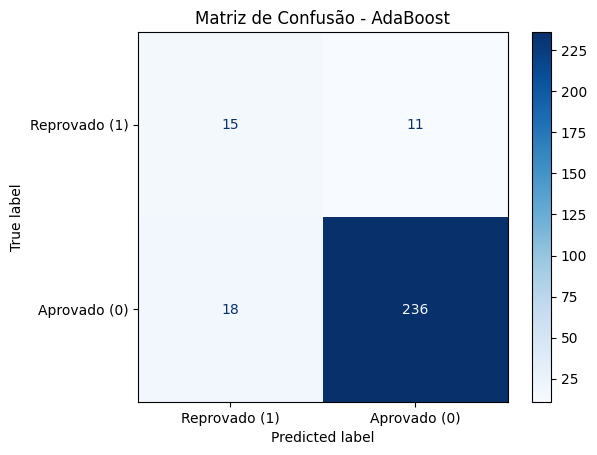

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Se ainda não dividiu os dados
# X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Aplicando SMOTE apenas no treino
sm = SMOTE(random_state=42)
X2_train, y2_train = sm.fit_resample(X2_train, y2_train)

# Definição do classificador (parâmetros default)
ab = AdaBoostClassifier(random_state=42)  # n_estimators=50, learning_rate=1.0

# Treinando o modelo
ab.fit(X2_train, y2_train)

# Previsões no conjunto de teste (sem SMOTE)
y2_pred = ab.predict(X2_test)

# Recall da classe 0
recall_classe_0 = recall_score(y2_test, y2_pred)
print("Recall da classe 0 no teste:", recall_classe_0)

# Matriz de confusão
cm = confusion_matrix(y2_test, y2_pred, labels=[1,0])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Reprovado (1)", "Aprovado (0)"]
)
disp.plot(cmap="Blues", values_format="d")

plt.title("Matriz de Confusão - AdaBoost")
plt.show()


Recall da classe 0 no teste: 0.6153846153846154


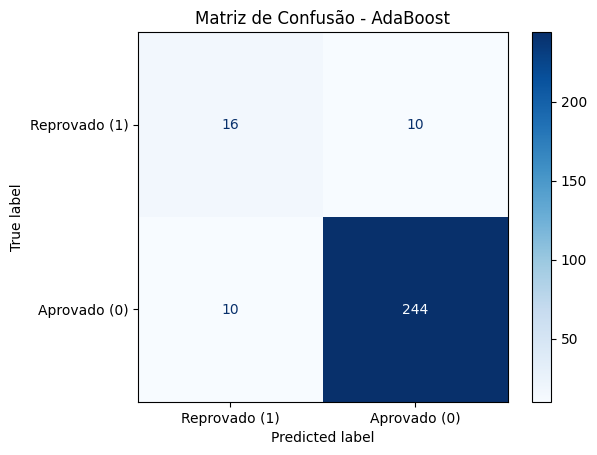

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Se ainda não dividiu os dados
# X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Aplicando SMOTE apenas no treino
sm = SMOTE(random_state=42)
X3_train, y3_train = sm.fit_resample(X3_train, y3_train)

# Definição do classificador (parâmetros default)
ab = AdaBoostClassifier(random_state=42)  # n_estimators=50, learning_rate=1.0

# Treinando o modelo
ab.fit(X3_train, y3_train)

# Previsões no conjunto de teste (sem SMOTE)
y3_pred = ab.predict(X3_test)

# Recall da classe 0
recall_classe_0 = recall_score(y3_test, y3_pred)
print("Recall da classe 0 no teste:", recall_classe_0)

# Matriz de confusão
cm = confusion_matrix(y3_test, y3_pred, labels=[1,0])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Reprovado (1)", "Aprovado (0)"]
)
disp.plot(cmap="Blues", values_format="d")

plt.title("Matriz de Confusão - AdaBoost")
plt.show()
